<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [1]:
# !pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers faiss-gpu openpyxl datasets langchain-community ragatouille umap-learn

In [2]:
# !pip install --ignore-installed huggingface-hub==0.20.3
# !pip uninstall huggingface-hub -y
# !pip install huggingface-hub==0.20.3
# !pip install --upgrade sentence-transformers
# !pip install pacmap
# !pip install -U bitsandbytes>=0.46.1
# !pip uninstall langchain-community -y
# !pip install langchain-community
# !pip install --upgrade sentence-transformers
# !pip install ragatouille

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['LANGCHAIN_WARNINGS'] = 'false'

import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm.notebook import tqdm
from langchain.docstore.document import Document as LangchainDocument
from langchain.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy

from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import random
from langchain.text_splitter import SpacyTextSplitter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
import umap
from sklearn.metrics.pairwise import cosine_similarity
from FlagEmbedding import FlagReranker

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

Используется устройство: cuda


In [5]:
os.makedirs('content', exist_ok=True)

In [6]:
# !nvidia-smi

## Загрузка данных (4 балла)

In [7]:
# url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
# output = 'file.csv'

# gdown.download(url, output, quiet=False)

# data = pd.read_csv('file.csv')

In [58]:
# Загрузка данных

file_id = '1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'content/file.csv'

if not os.path.exists(output):
    gdown.download(id=file_id, output=output, quiet=False)

In [59]:
data = pd.read_csv(output).drop('Unnamed: 0', axis=1, errors='ignore')

In [60]:
# data.sample(500)
data.sample(3)

,Name,WikiData,City,Lon,Lat,description,image,en_txt
2691,Усадьба ротмистра Переяславцева,Q27890562,Екатеринбург,60.611946,56.836205,Усадьба ротмистра Переяславцева,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,two pictures of a building that has been destr...
3981,Нижегородский Кремль,Q100270892,Нижний Новгород,44.005554,56.327255,"историческое здание в Нижнем Новгороде, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed view of a castle on a hill with a river...
5352,Локомотив,Q2503505,Нижний Новгород,43.929649,56.309647,"многоцелевой стадион в Нижнем Новгороде, Россия",/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,a close up of a group of different soccer team...


In [61]:
data['City'].unique()

<ArrowStringArray>
['Екатеринбург', 'Нижний Новгород', 'Владимир', 'Ярославль']
Length: 4, dtype: str

Проверим датасет на предмет пропусков

In [62]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 14634 entries, 0 to 14633
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         14634 non-null  str    
 1   WikiData     12078 non-null  str    
 2   City         14634 non-null  str    
 3   Lon          14634 non-null  float64
 4   Lat          14634 non-null  float64
 5   description  12078 non-null  str    
 6   image        14634 non-null  str    
 7   en_txt       14634 non-null  str    
dtypes: float64(2), str(6)
memory usage: 641.0 MB


In [63]:
data.isna().sum()

Name              0
WikiData       2556
City              0
Lon               0
Lat               0
description    2556
image             0
en_txt            0
dtype: int64

Удалим строки с пропусками в WikiData и проверим датасет еще раз на предмет пропусков

In [64]:
data = data.dropna(subset=['WikiData'])

data.isna().sum()

Name           0
WikiData       0
City           0
Lon            0
Lat            0
description    0
image          0
en_txt         0
dtype: int64

In [65]:
# sorted(data['WikiData'].unique(), reverse=True)
# sorted(data['description'].unique(), reverse=False)
sorted(data['en_txt'].unique(), reverse=True)

['прррмомоннннннннннн',
 'yellow house with a black roof and a white fence',
 'yellow flowers in front of a brick building with a clock tower',
 'yellow church with blue domes and a clock tower in a city',
 'yellow church with a golden dome on a sunny day',
 'yellow church with a golden dome on a cloudy day',
 'yellow church with a golden dome and a steeple on a street corner',
 'yellow church with a golden dome and a cross on top',
 'yellow church with a blue dome and a cross on the front',
 'yellow bus parked in front of a large yellow building with a green roof',
 'yellow building with white trim and windows on a sunny day',
 'yellow building with white trim and windows on a street corner',
 'yellow building with white trim and windows in winter time',
 'yellow building with white trim and windows in snow covered area',
 'yellow building with white trim and windows and a sign on the front',
 'yellow building with white trim and windows',
 'yellow building with white trim and columns

In [66]:
# В колонке 'en_txt' замечено значение 'прррмомоннннннннннн', заменим его на моду

mask = data['en_txt'] == 'прррмомоннннннннннн'
name_field = data[mask]['Name'].iloc[0]
print(name_field)

mode_value = data[data['Name'] == name_field]['en_txt'].mode()[0]
print(mode_value)

data.loc[mask, 'en_txt'] = mode_value

Ярославский дворец молодёжи
there is a building with a sign on the top of it


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [67]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [68]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

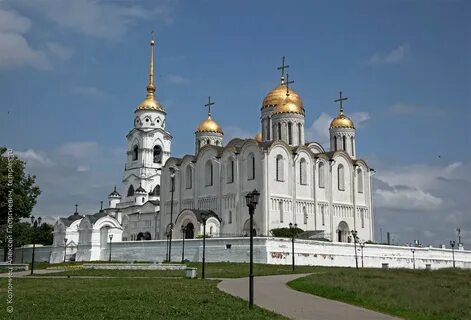

In [160]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - самое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

Проверим датасет на предмет пропусков

Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

Вместо RAGatouille из ragatouille буду использорвать альтернативу (FlagReranker)

In [20]:
df = data.drop('en_txt', axis = 1)

In [21]:
df['desc_len'] = df['description'].str.len()

df = df.sort_values('desc_len', ascending=False)

df_grouped = df.groupby('WikiData').agg({
    'Name': lambda x: x.value_counts().idxmax(),
    'City': lambda x: x.value_counts().idxmax(),
    'Lon': 'mean',
    'Lat': 'mean',
    'description': 'first',
    'image': lambda x: list(x),
}).reset_index()

data = df_grouped
data.head()

,WikiData,Name,City,Lon,Lat,description,image
0,Q100270892,Нижегородский Кремль,Нижний Новгород,44.005554,56.327255,"историческое здание в Нижнем Новгороде, Россия",[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...
1,Q100701435,Гарнизонная казарма,Нижний Новгород,44.004299,56.327614,"здание в Нижегородском кремле, Россия",[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...
2,Q100882660,Губернаторский сад,Нижний Новгород,44.005272,56.329803,"парк в Нижегородском кремле, Россия",[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...
3,Q104554178,Церковь Николы в Меленках,Ярославль,39.834522,57.609947,Православный храм в Ярославле,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...
4,Q104776528,Церковь в честь Преображения Господня,Нижний Новгород,44.072117,56.318909,Спасо-Преображенская церковь (Старые Печёры),[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...


In [22]:
# TF-IDF для выявления и удаления выбросов

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))

tfidf_matrix = tfidf.fit_transform(data['description'].fillna(''))

avg_tfidf = np.array(tfidf_matrix.mean(axis=1)).flatten()
data['tfidf_score'] = avg_tfidf

# Отсечение (100 - percentile)% текстов с наибольшим TF‑IDF скором
percentile = 95
threshold = np.percentile(avg_tfidf, percentile)
data['is_outlier'] = data['tfidf_score'] > threshold

clean_data = data[~data['is_outlier']].copy()

# Стратификация (выбор образцов: Город-Достопримечательность)
clean_data['group_key'] = clean_data['City'].astype(str) + '||' + clean_data['Name'].astype(str)

stratified_data = clean_data.groupby('group_key', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 1), random_state=42)
).reset_index(drop=True)

if 'group_key' in stratified_data.columns:
    stratified_data = stratified_data.drop(columns=['group_key'])

print(f'Чистых записей: {len(clean_data)}')
print(f'Удалено выбросов: {data['is_outlier'].sum()}')
print(f'Итоговый размер выборки: {len(stratified_data)}')

Чистых записей: 281
Удалено выбросов: 15
Итоговый размер выборки: 281


In [23]:
stratified_data.sample(5)

,WikiData,Name,City,Lon,Lat,description,image,tfidf_score,is_outlier
117,Q4165268,Дом Болконского,Ярославль,39.900871,57.625092,Дом Болконского,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.001642,False
213,Q4525185,Школа № 33 имени Карла Маркса,Ярославль,39.881363,57.628075,Школа № 33 имени Карла Маркса,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.002923,False
66,Q2403914,Спасо-преображенский собор,Нижний Новгород,43.872032,56.349922,православный храм в Нижнем Новгороде,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.002526,False
42,Q18331765,Церковь Никиты Великомученика,Владимир,40.397797,56.130745,Никитская церковь,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.001648,False
6,Q107506739,Серго Орджоникидзе,Екатеринбург,60.592449,56.885479,Памятник в Екатеринбурге,[/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFB...,0.001648,False


In [24]:
documents = []
for _, row in stratified_data.iterrows():
    # Объединение текста для получения большей информации
    full_text = f"Название: {row['Name']}, Город: {row['City']}, Описание: {row['description']}"
    
    # Создаeм документ для RAG
    doc = LangchainDocument(
        page_content=full_text,  
        metadata={               
            'image': row['image'],
            'description': row['description'],
            'name': row['Name'],
            'city': row['City'],
            'lon': row['Lon'],
            'lat': row['Lat'],
            'wikidata': row['WikiData']
        }
    )
    documents.append(doc)
print(f'Всего записей {len(documents)}')

Всего записей 281


Настройка RAG

In [54]:
# Создание эмбеддингов

model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'

embeddings = HuggingFaceEmbeddings(
    model_name=model_name,
    model_kwargs={'device': 'cpu'},
    encode_kwargs={'normalize_embeddings': True}
)

In [26]:
# Создание чанков

text_splitter = SpacyTextSplitter(
    pipeline='ru_core_news_sm', 
    chunk_size=500,
    chunk_overlap=50
)

chunks = text_splitter.split_documents(documents)

print(f'Создано {len(chunks)} чанков из {len(documents)} документов')
print(f'Пример чанка: {chunks[16].page_content}...')

Создано 281 чанков из 281 документов
Пример чанка: Название: Мемориальный дом-музей М. Богдановича, Город: Ярославль, Описание: Мемориальный дом-музей М. Богдановича...


In [27]:
# Векторное хранилище

vectorstore = FAISS.from_documents(
    documents=chunks,  
    embedding=embeddings,  
    distance_strategy=DistanceStrategy.COSINE)

In [28]:
# Загрузка модели переранжировщика

os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
reranker_model = FlagReranker('BAAI/bge-reranker-large', use_fp16=True)

In [29]:
def retrieve_and_rerank(question, k=5, rerank_k=10):
    """
    Поиск с переранжированием
    """
    # Начальный поиск
    initial_results = vectorstore.similarity_search(question, k=rerank_k)
    
    if not initial_results:
        return []
    
    # Переранжирование
    pairs = [[question, doc.page_content] for doc in initial_results]
    scores = reranker_model.compute_score(pairs)
    
    for doc, score in zip(initial_results, scores):
        doc.metadata['relevance_score'] = float(score)
    
    # Сортировка
    sorted_results = sorted(initial_results, key=lambda x: x.metadata['relevance_score'], reverse=True)
    
    # Формирование результатов
    final_results = []
    for res in sorted_results[:k]:
        final_results.append({
            'content': res.page_content,
            'detailed': res.metadata.get('detailed_text', res.page_content),
            'metadata': res.metadata,
            'score': res.metadata['relevance_score']
        })
    
    return final_results

In [30]:
# Проверка

question = 'Какие достопримечательности есть в Нижнем Новгороде?'

In [31]:
answer = retrieve_and_rerank(question)
for i in range(len(answer)):
    print(answer[i]['content'])

You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Название: Нижегородский Кремль, Город: Нижний Новгород, Описание: историческое здание в Нижнем Новгороде, Россия
Название: Усадьба Вяхиревых, Город: Нижний Новгород, Описание: Усадьба Вяхиревых
Название: Чкаловская лестница, Город: Нижний Новгород, Описание: лестница на Волжском откосе в Нижнем Новгороде
Название: Усадьба Киршбаумов, Город: Нижний Новгород, Описание: Усадьба Киршбаумов
Название: Дом А. К. Фомина, Город: Нижний Новгород, Описание: памятник


Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [32]:
# Список текстов и список эмбеддингов
texts = [chunk.page_content for chunk in chunks]
embeddings_list = embeddings.embed_documents(texts)

# Извлекаем города из метаданных
cities = [chunk.metadata.get('city', 'Unknown') for chunk in chunks]

# Палитра цветов для городов
unique_cities = list(set(cities))
color_palette = ['red', 'blue', 'green', 'orange', 'purple']
city_to_color = {city: color_palette[i % len(color_palette)] for i, city in enumerate(unique_cities)}

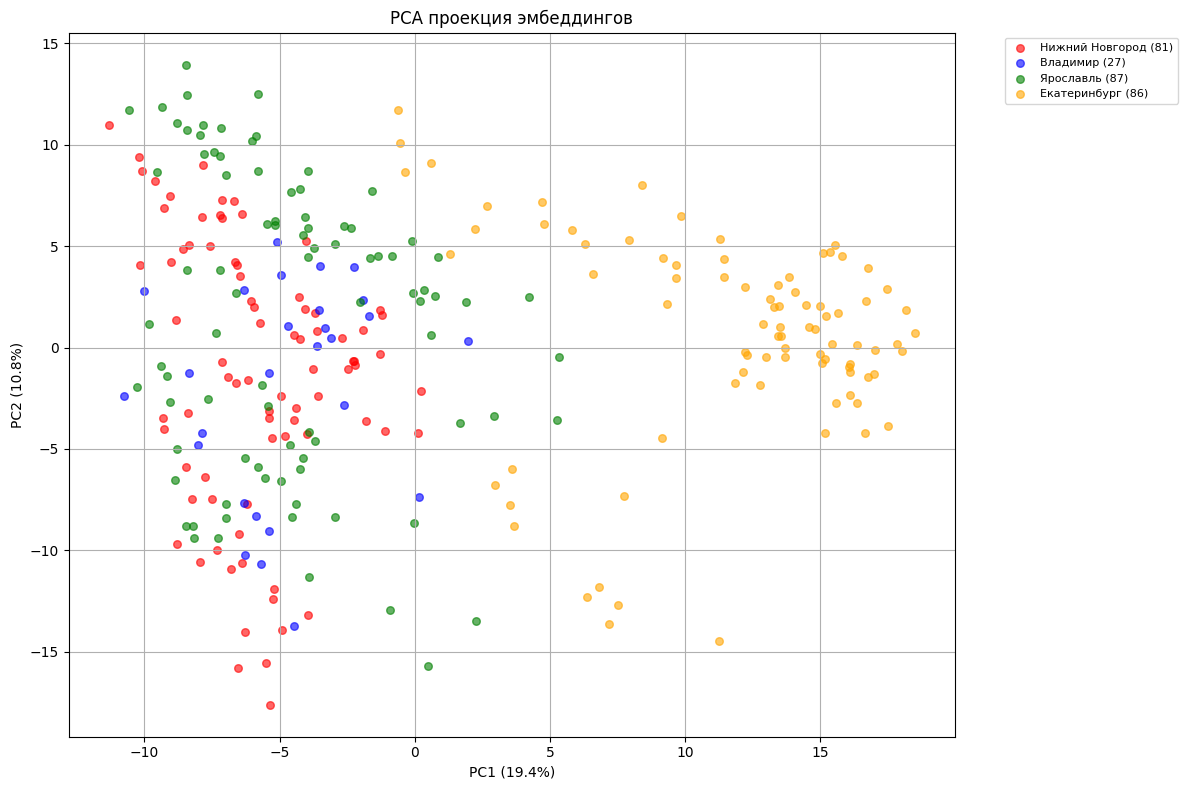

In [33]:
# Масштабирование эмбеддингов для PCA

scaler = StandardScaler()
sample_embeddings_scaled = scaler.fit_transform(embeddings_list)

# Настройка PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(sample_embeddings_scaled)
explained_variance = pca.explained_variance_ratio_

# Визуализация PCA
plt.figure(figsize=(12, 8))

for city in unique_cities:
    # Маска для текущего города во всем наборе данных
    mask = [c == city for c in cities]
    if sum(mask) == 0:  # пропуск, если город не найден
        continue
    
    plt.scatter(
        pca_result[mask, 0],
        pca_result[mask, 1],
        label=f'{city} ({sum(mask)})',
        alpha=0.6,
        s=30,
        color=city_to_color[city]
    )

plt.title('PCA проекция эмбеддингов', fontsize=12)
plt.xlabel(f'PC1 ({explained_variance[0]:.1%})', fontsize=10)
plt.ylabel(f'PC2 ({explained_variance[1]:.1%})', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid()
plt.tight_layout()

plt.show()

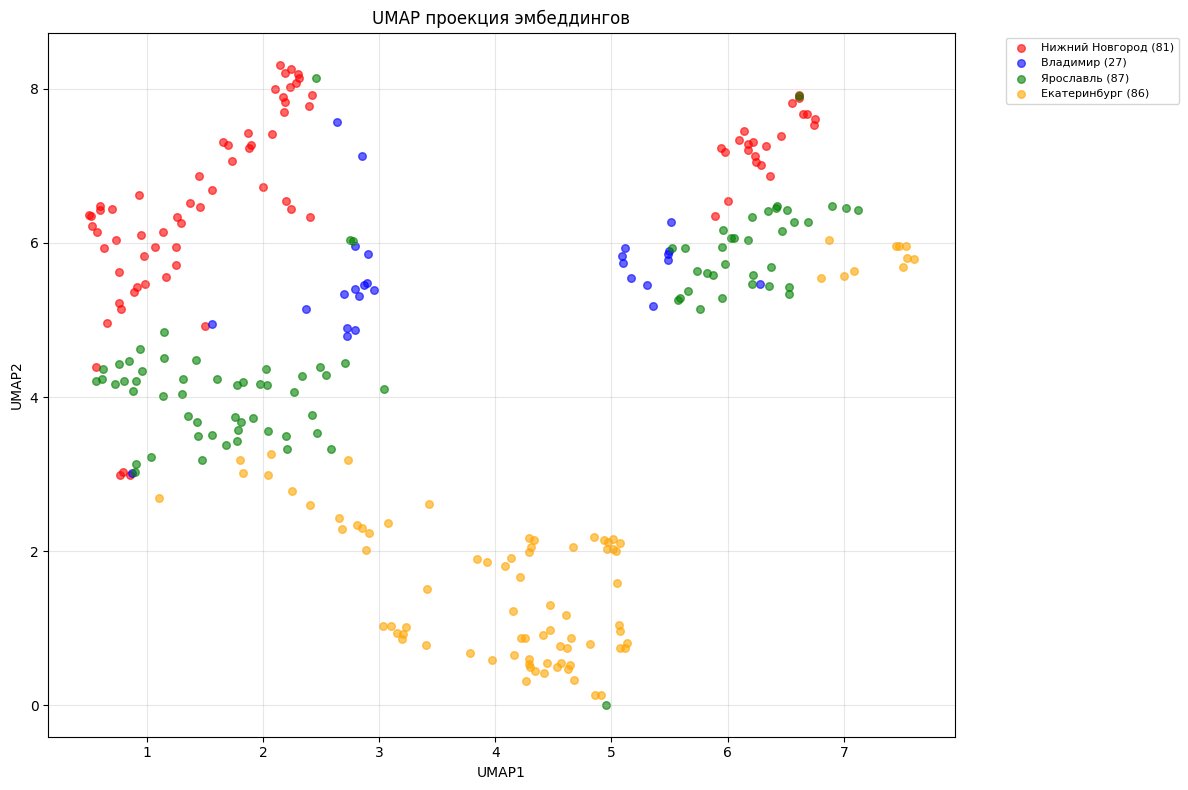

In [34]:
# Масштабирование эмбеддингов для UMAP

scaler_mm = MinMaxScaler()
sample_embeddings_mm = scaler_mm.fit_transform(embeddings_list)

# Настройка UMAP
umap_reducer = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
umap_result = umap_reducer.fit_transform(sample_embeddings_mm)

# Визуализация UMAP
plt.figure(figsize=(12, 8))

for city in unique_cities:
    # Маска для текущего города во всем наборе данных
    mask = [c == city for c in cities]
    if sum(mask) == 0:  # пропуск, если город не найден
        continue

    plt.scatter(
        umap_result[mask, 0],
        umap_result[mask, 1],
        label=f'{city} ({sum(mask)})',
        alpha=0.6,
        s=30,
        color=city_to_color[city]
    )

plt.title('UMAP проекция эмбеддингов', fontsize=12)
plt.xlabel('UMAP1', fontsize=10)
plt.ylabel('UMAP2', fontsize=10)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при еe интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [35]:
def make_prompt(results, question):
    """
    Создание промпта для модели
    """
    main_res = results[0]
    other_res = results[1:]
    
    main_metadata = main_res['metadata']
    main_context = f"""
    {main_metadata.get('name', '')} находится в городе {main_metadata.get('city', '')}. 
    Это {main_metadata.get('description', '')}. 
    Он расположен на широте {main_metadata.get('lat', '')} и долготе {main_metadata.get('lon', '')}.
    Более подробную информацию можно узнать на викидате, ID - {main_metadata.get('wikidata', '')}.
    """
    
    other_data = [f"{x['metadata'].get('name', '')} в городе {x['metadata'].get('city', '')}" 
                  for x in other_res]
    other_context = ' '.join(other_data)
    
    result_prompt = f"""
    <|im_start|>system
    Ты помощник туриста. Отвечай естественно, как человек, на русском языке.
    <|im_end|>
    <|im_start|>user
    Контекст: {main_context}
    Дополнительные данные: {other_context}
    Вопрос: {question}

    Используй только информацию из контекста. Если не знаешь - честно признайся, но предложи помощь в другом вопросе.
    <|im_end|>
    <|im_start|>assistant
    """
    return result_prompt, main_context, other_context

In [36]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

model_answer_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_answer_name)
tokenizer.pad_token = tokenizer.eos_token

model_answer = AutoModelForCausalLM.from_pretrained(
    model_answer_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [37]:
def get_answer(question, k=3):
    results = retrieve_and_rerank(question, k=k)
    prompt, main_context, other_context = make_prompt(results, question)

    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=1500).to(model_answer.device)

    outputs = model_answer.generate(
        **inputs,
        max_new_tokens=250,
        do_sample=True,
        temperature=0.3,
        top_p=0.9,
        repetition_penalty=1.1,
        pad_token_id=tokenizer.eos_token_id
    )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    assistant_marker = "<|im_start|>assistant"
    if assistant_marker in full_text:
        answer = full_text.split(assistant_marker)[-1].strip()
    else:

        parts = full_text.split("assistant")
        answer = parts[-1].strip() if len(parts) > 1 else full_text

    context = f'''
    Информация о самом релевантном объекте: {main_context}
    Дополнительно: {other_context}
    '''

    images = results[0]['metadata']['image'] if results else []

    del inputs, outputs
    torch.cuda.empty_cache()

    return answer, context, images

Нижегородский Кремль — это историческое здание, расположенное в Нижнем Новгороде, России. Его географические координаты — широта 56.327255 и долгота 44.005554.

    Этот кремль является важным архитектурным памятником и представляет собой часть города с историческим значением. Однако у меня нет дополнительной информации о конкретных достопримечательностях внутри кремля, таких как Георгиевская башня или Гарнизонная казарма. Для получения более детальной информации рекомендую обратиться к официальным источникам или посетить сайт википедии с указанным ID Q100270892 для получения полного списка доступных данных. 

    Если вам нужна информация о других достопримечательностях Нижнего Новгорода, я буду рад помочь!


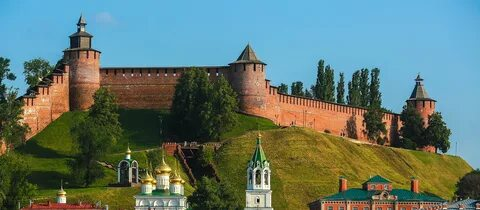

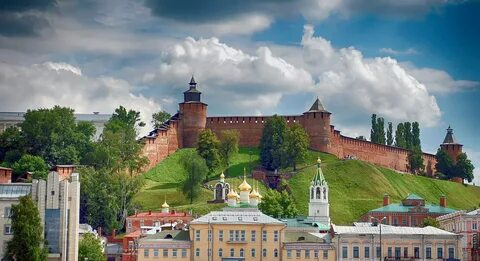

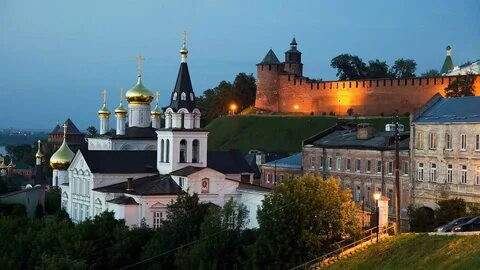

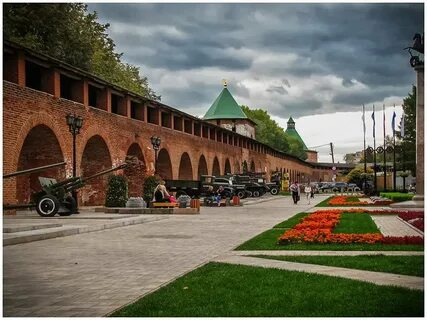

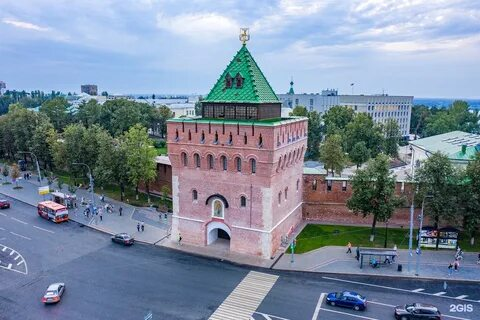

In [38]:
question = 'Расскажи про Нижегородский Кремль'

answer, context, images = get_answer(question)
print(answer)

for img in images[:5]:
    display(get_image(img))

In [39]:
def answer_relevancy(question=None, answer=None, embedding_model=embeddings):

    # Эмбеддинги
    question_emb = embedding_model.embed_query(question)
    answer_emb = embedding_model.embed_query(answer)
    
    # Подготовка для анализа через cosine_similarity
    question_emb_array = np.array(question_emb).reshape(1, -1)
    answer_emb_array = np.array(answer_emb).reshape(1, -1)
    
    # Косинусное сходство
    similarity = cosine_similarity(question_emb_array, answer_emb_array)[0][0]
    
    # Штраф за слишком короткие ответы
    length_penalty = min(1.0, len(answer.split()) / 30)
    
    return similarity * length_penalty

# Протестируйте ваш RAG (3 балла)

Создадим по 4-6 вопросов разной категории. Сохраним категорию в метаданные для дальнейшего анализа.

In [43]:
test_questions = []
test_metadata = []

# Создание списков с уникальными городами и достопримечательностями
unique_cities = stratified_data['City'].unique()
unique_places = stratified_data[['Name', 'City']].drop_duplicates()

# Вопросы о том, какие достопримечательности есть в городе
for city in unique_cities:
    test_questions.append(f'Какие достопримечательности или интересные места есть в городе {city}?')
    test_metadata.append({'type': 'Достопримечательности в городе', 'city': city, 'name': None})

# Вопросы о конкретной достопримечательности
sample_places = unique_places.sample(n=6, random_state=42)
for _, row in sample_places.iterrows():
    test_questions.append(f'Расскажите о {row["Name"]} в городе {row["City"]}')
    test_metadata.append({'type': 'Описание', 'city': row['City'], 'name': row['Name']})

# Вопросы о том, какие музеи есть в городе
for city in unique_cities:
    test_questions.append(f'Какие музеи есть в городе {city}?')
    test_metadata.append({'type': 'Музеи в городе', 'city': city, 'name': None})

# Вопросы о местоположении достопримечательности
sample_places = unique_places.sample(n=6, random_state=4721)
for _, row in sample_places.iterrows():
    test_questions.append(f'В каком городе находится {row["Name"]}?')
    test_metadata.append({'type': 'Город по достопримечательности', 'city': row['City'], 'name': row['Name']})

# Вопросы о ближайших достопримечательностях
sample_places_nearby = unique_places.sample(n=5, random_state=7956)
for _, row in sample_places_nearby.iterrows():
    test_questions.append(f'Что находится рядом с {row["Name"]} в городе {row["City"]}?')
    test_metadata.append({'type': 'Ближайшие достопримечательности или интересные места', 'city': row['City'], 'name': row['Name']})

print(f'Создано тестовых вопросов: {len(test_questions)}')

Создано тестовых вопросов: 25


In [45]:
# Результаты тестирования на 10 случайных вопросах

sample_questions = random.sample(test_questions, 10)
for question in sample_questions:
    print(f'\nВопрос: {question}')
    answer, context, images = get_answer(question)
    print(f'Ответ: {answer}')
    relevancy = answer_relevancy(question, answer)
    print(f'Answer Relevancy: {relevancy:.4f}')


Вопрос: В каком городе находится Северная башня?
Ответ: Северная башня находится в городе Нижний Новгород.
Answer Relevancy: 0.1420

Вопрос: Какие достопримечательности или интересные места есть в городе Владимир?
Ответ: В городе Владимир находятся несколько интересных достопримечательностей:

1. **Бывшая водонапорная башня** — это исторический объект, который стоит посетить для того, чтобы увидеть его строение и узнать больше о истории города.

2. **Владимирский централь** — возможно, это вокзал или станция железнодорожного сообщения, так как часто называют городские вокзалы "центрами".

3. **Золотые ворота** — это архитектурный памятник, который также стоит посмотреть.

Если вам нужна более детальная информация о каждом из этих местах, вы можете найти дополнительные сведения на википедии по соответствующим ID-номерам (Q4114100 для башни). 

Если у вас есть еще вопросы или нужно что-то конкретное узнать, дайте знать!
Answer Relevancy: 0.8118

Вопрос: Какие музеи есть в городе Екатери

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

Посмотрим на вопросы тестового списка и посчитаем общие метрики и релевантность по категориям.

Оценка Answer Relevancy

In [46]:
# Посмотрим на тестовые вопросы, сгенерированные ранее

for i, question in enumerate(test_questions, start=1):
    print(f'{i}. {question}')

1. Какие достопримечательности или интересные места есть в городе Нижний Новгород?
2. Какие достопримечательности или интересные места есть в городе Ярославль?
3. Какие достопримечательности или интересные места есть в городе Екатеринбург?
4. Какие достопримечательности или интересные места есть в городе Владимир?
5. Расскажите о Церковь Александра Невского в Сормово в городе Нижний Новгород
6. Расскажите о Колокольня Никитского прихода в городе Ярославль
7. Расскажите о Храм на Крови в городе Екатеринбург
8. Расскажите о Дом Е. Трушенинниковой в городе Нижний Новгород
9. Расскажите о Владимирская духовная семинария в городе Владимир
10. Расскажите о Комсомолу Урала в городе Екатеринбург
11. Какие музеи есть в городе Нижний Новгород?
12. Какие музеи есть в городе Ярославль?
13. Какие музеи есть в городе Екатеринбург?
14. Какие музеи есть в городе Владимир?
15. В каком городе находится Музей истории, науки и техники Свердловской железной дороги?
16. В каком городе находится Церковь Алек

Будем оценивать общую релевантность и релевантность по типу вопроса

In [47]:
# Словарь для хранения результатов по типам вопросов
results_by_type = {}

# Оценка для каждого вопроса с сохранением типа вопроса
for i, (question, metadata) in enumerate(tqdm(zip(test_questions, test_metadata), 
                                desc='Оценка релевантности', total=len(test_questions))):
    
    answer, context, images = get_answer(question)
    relevancy = answer_relevancy(question, answer)
    
    question_type = metadata['type']
    
    # Инициализация типа в словаре, если его еще нет
    if question_type not in results_by_type:
        results_by_type[question_type] = {
            'scores': [],
            'questions': [],
            'answers': [],
            'cities': [],
            'names': []
        }
    
    # Сохранение результатов
    results_by_type[question_type]['scores'].append(relevancy)
    results_by_type[question_type]['questions'].append(question)
    results_by_type[question_type]['answers'].append(answer)
    results_by_type[question_type]['cities'].append(metadata['city'])
    if metadata['name']:
        results_by_type[question_type]['names'].append(metadata['name'])
    
    torch.cuda.empty_cache()

Оценка релевантности:   0%|          | 0/25 [00:00<?, ?it/s]

In [48]:
# Общая статистика

all_scores = []
for q_type, data in results_by_type.items():
    all_scores.extend(data['scores'])
    
avg_all_scores = np.mean(all_scores)
min_all_scores = np.min(all_scores)
max_all_scores = np.max(all_scores)
    
print(f'Всего вопросов:             {len(all_scores)}')
print(f'Средняя Answer Relevancy:   {avg_all_scores:.4f}')
print(f'Минимум Answer Relevancy:   {min_all_scores:.4f}')
print(f'Максимум Answer Relevancy:  {max_all_scores:.4f}')

Всего вопросов:             25
Средняя Answer Relevancy:   0.7007
Минимум Answer Relevancy:   0.1255
Максимум Answer Relevancy:  0.9109


In [49]:
# Статистика по каждому типу

for q_type, data in results_by_type.items():
    scores = data['scores']
    avg_score = np.mean(scores)
    min_score = np.min(scores)
    max_score = np.max(scores)
    
    print(f'\n{q_type.upper()}:')
    print(f'Всего вопросов:             {len(scores)}')
    print(f'Средняя Answer Relevancy:   {avg_score:.4f}')
    print(f'Минимум Answer Relevancy:   {min_score:.4f}')
    print(f'Максимум Answer Relevancy:  {max_score:.4f}')


ДОСТОПРИМЕЧАТЕЛЬНОСТИ В ГОРОДЕ:
Всего вопросов:             4
Средняя Answer Relevancy:   0.8553
Минимум Answer Relevancy:   0.8289
Максимум Answer Relevancy:  0.8978

ОПИСАНИЕ:
Всего вопросов:             6
Средняя Answer Relevancy:   0.7981
Минимум Answer Relevancy:   0.6990
Максимум Answer Relevancy:  0.8822

МУЗЕИ В ГОРОДЕ:
Всего вопросов:             4
Средняя Answer Relevancy:   0.8652
Минимум Answer Relevancy:   0.8348
Максимум Answer Relevancy:  0.9109

ГОРОД ПО ДОСТОПРИМЕЧАТЕЛЬНОСТИ:
Всего вопросов:             6
Средняя Answer Relevancy:   0.2777
Минимум Answer Relevancy:   0.1255
Максимум Answer Relevancy:  0.7545

БЛИЖАЙШИЕ ДОСТОПРИМЕЧАТЕЛЬНОСТИ ИЛИ ИНТЕРЕСНЫЕ МЕСТА:
Всего вопросов:             5
Средняя Answer Relevancy:   0.8362
Минимум Answer Relevancy:   0.7709
Максимум Answer Relevancy:  0.8828


In [ ]:
# Лучший и худший ответ на вопрос среди всех ответов

all_scores = []
all_questions = []
all_answers = []

for q_type, data in results_by_type.items():
    all_scores.extend(data['scores'])
    all_questions.extend(data['questions'])
    all_answers.extend(data['answers'])

all_scores = np.array(all_scores)
all_questions = np.array(all_questions)
all_answers = np.array(all_answers)

# Индексы лучшего и худшего ответа
best_idx = np.argmax(all_scores)
worst_idx = np.argmin(all_scores)

print(f'\nЛучший Answer Relevancy: {all_scores[best_idx]:.4f}:')
print(f'Вопрос: {all_questions[best_idx]}')
print(f'Ответ: {all_answers[best_idx]}')

print(f'\nХудший Answer Relevancy: {all_scores[worst_idx]:.4f}):')
print(f'Вопрос: {all_questions[worst_idx]}')
print(f'Ответ: {all_answers[worst_idx]}')


Лучший Answer Relevancy: 0.9109:
Вопрос: Какие музеи есть в городе Екатеринбург?
Ответ: В городе Екатеринбург есть несколько музеев:

1. Музей истории Екатеринбурга
2. Художественный Музей Эрнста Неизвестного

Если вам нужно больше информации о этих музеях или их расположении, вы можете посмотреть дополнительные данные в викидатах, которые указаны в контексте.

Худший Answer Relevancy: 0.1255):
Вопрос: В каком городе находится Суворовское училище?
Ответ: Суворовское училище находится в городе Екатеринбург.


Оценка Context Recall

In [51]:
# Промт для оценки полносты контекста

def make_prompt_for_recall(model_answer, context):
    return f'''
    <|im_start|>system
    Ты должен оценить, сколько данных из контекста было использовано в ответе.
    <|im_end|>
    <|im_start|>user
    Контекст: {context}
    Ответ для оценки: {model_answer}

    Критерии оценки:
    - 1.0: Использована вся информация из контекста (все ключевые факты, названия, детали)
    - 0.8: Использована большая часть информации (>70%)
    - 0.6: Использована половина информации (~50%)
    - 0.4: Использована меньшая часть информации (<30%)
    - 0.2: Использовано минимум информации (только отдельные фрагменты)
    - 0.0: Информация из контекста не использована или ответ говорит "я не знаю"
    
    Учитывай только информацию из контекста
    Ответь только числом от 0.0 до 1.0, без пояснений
    <|im_end|>
    <|im_start|>assistant
    '''

In [53]:
# Оценка Context Recall

def context_recall(context, answer):
    prompt = make_prompt_for_recall(answer, context)
    inputs = tokenizer(prompt, return_tensors="pt").to(model_answer.device)
    outputs = model_answer.generate(
        **inputs,
        max_new_tokens=10,
        do_sample=True,
        temperature=0.1,
        pad_token_id=tokenizer.eos_token_id
    )
    fullanswer = tokenizer.decode(outputs[0], skip_special_tokens=True)
    result = fullanswer.split('assistant')[-1].strip()

    score = float(result)
    if 0 <= score <= 1:
        return score
    else:
        return 0.0


recall_scores = []
for idx, question in enumerate(tqdm(test_questions, desc='Оценка полноты контекста')):
    answer, context, images = get_answer(question)
    score = context_recall(context, answer)
    recall_scores.append(score)
    torch.cuda.empty_cache()

avg_recall_scores = np.mean(recall_scores)
min_recall_scores = np.min(recall_scores)
max_recall_scores = np.max(recall_scores)

print(f'Всего вопросов:            {len(recall_scores)}')
print(f'Средняя Context Recall:    {avg_recall_scores:.4f}')
print(f'Минимум Context Recall:    {min_recall_scores:.4f}')
print(f'Максимум Context Recall:   {max_recall_scores:.4f}')

Оценка полноты контекста:   0%|          | 0/25 [00:00<?, ?it/s]

Всего вопросов:            25
Средняя Context Recall:    0.6960
Минимум Context Recall:    0.2000
Максимум Context Recall:   0.8000
